<font size="5"><center>Taller de procesamiento de señales

<font size="5">Trabajo práctico N°11

<font size="5">Alumno: Santiago Cabrera

<font size="5">Padrón: 110.445

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import arviz as az

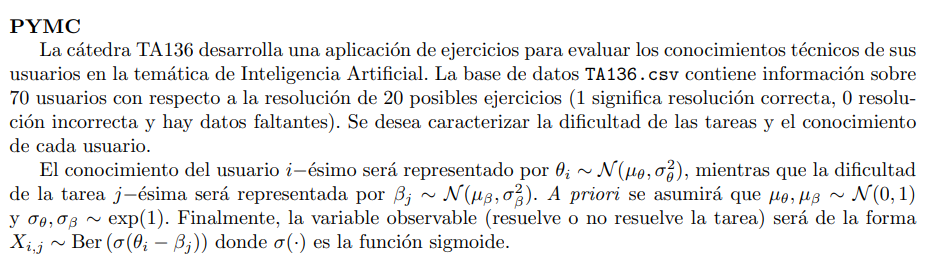

# a) Cargar la base de datos TA136.csv y reemplazar los datos faltantes por np.nan

In [ ]:
!wget https://github.com/mvera1412/TA136-TB056-TB057-8625/raw/refs/heads/main/data/TA136.csv

--2025-11-26 01:19:46--  https://github.com/mvera1412/TA136-TB056-TB057-8625/raw/refs/heads/main/data/TA136.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/TA136.csv [following]
--2025-11-26 01:19:46--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/TA136.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6109 (6.0K) [text/plain]
Saving to: ‘TA136.csv’

TA136.csv           100%[===================>]   5.97K  --.-KB/s    in 0s      

2025-11-26 01:19:46 (61.9 MB/s) - ‘TA136.csv’ saved [6109/610

In [ ]:
datos = pd.read_csv('TA136.csv')
datos.head()

,Unnamed: 0,item 0,item 1,item 2,item 3,item 4,item 5,item 6,item 7,item 8,...,item 10,item 11,item 12,item 13,item 14,item 15,item 16,item 17,item 18,item 19
0,usuario 0,1.0,0.0,1.0,NaN,0.0,0.0,1.0,1.0,NaN,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
1,usuario 1,1.0,0.0,0.0,NaN,0.0,NaN,1.0,1.0,0.0,...,0.0,0.0,1.0,NaN,1.0,0.0,1.0,1.0,0.0,1.0
2,usuario 2,1.0,NaN,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
3,usuario 3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,usuario 4,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,...,0.0,1.0,NaN,1.0,1.0,0.0,0.0,1.0,1.0,0.0


Se observa que los datos faltantes ya son np.nan

# b)  Construir el modelo bayesiano antes descripto en PyMC.

In [ ]:
X = datos.drop(columns=['Unnamed: 0']).to_numpy() #tiro la columna con los tags de los usuraios
N_usuarios, N_tareas = X.shape
print(f'Hay {N_usuarios} usuarios y {N_tareas} tareas')

Hay 70 usuarios y 20 tareas


In [ ]:
with pm.Model() as modelo:
  mu_thita = pm.Normal('mu_thita', mu = 0, sigma = 1)
  sigma_thita = pm.Exponential('sigma_thita', lam = 1)

  mu_beta = pm.Normal('mu_beta', mu = 0, sigma = 1)
  sigma_beta = pm.Exponential('sigma_beta', lam = 1)

  thita = pm.Normal('thita', mu = mu_thita, sigma = sigma_thita, shape = N_usuarios) #desempeño del usuario

  beta = pm.Normal('beta', mu = mu_beta, sigma = sigma_beta, shape = N_tareas) #dificultad de la tarea

  logit_p = thita[:, None] - beta[None, :]

  X_obs = pm.Bernoulli('X_obs', logit_p = logit_p, observed = X)

  trace = pm.sample(draws = 100, tune = 100, chains = 1)

/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1305: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
/usr/local/lib/python3.12/dist-packages/pymc/model/core.py:1319: ImputationWarning: Data in X_obs contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


Output()

#c) Utilizando model_to_graphviz (PyMC), graficar la red bayesiana. ¿C´omo interpreta la red los datos faltantes?

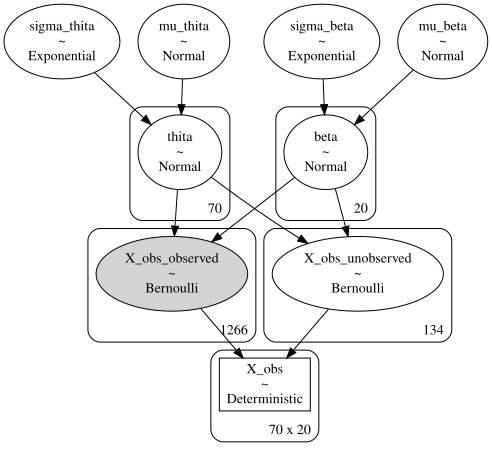

In [ ]:
pm.model_to_graphviz(modelo)

In [ ]:
#¿Cuantos nans hay?
nans = np.isnan(X).sum()
print(f'Hay {nans} datos faltantes')

Hay 134 datos faltantes


La red no descarta los 134 datos faltantes, sino que crea un nodo donde los datos faltantes son variables aleatorias.

#d) Muestrear 3 cadenas del experimento. Elegir los parámetros draws, tune y target accept de manera de alcanazar un ESS (bulk) > 30 y un $\hat{R}$ menor o igual que 1.1, en todos los $\theta_i$ y $\beta_j$

In [ ]:
with modelo:
  trace = pm.sample(draws = 4000, tune = 4000, chains = 3, target_accept = 0.9)

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
resumen = az.summary(trace, var_names = ['thita', 'beta'], round_to = 3)
resumen = resumen[['ess_bulk', 'r_hat']]
print(resumen)

ess_bulk = resumen['ess_bulk'].values
r_hat = resumen['r_hat'].values



          ess_bulk  r_hat
thita[0]    61.587  1.057
thita[1]    60.017  1.062
thita[2]    61.909  1.057
thita[3]    61.580  1.058
thita[4]    63.838  1.057
...            ...    ...
beta[15]    54.957  1.064
beta[16]    49.339  1.074
beta[17]    52.583  1.070
beta[18]    48.614  1.075
beta[19]    49.607  1.073

[90 rows x 2 columns]


In [ ]:
if np.any(ess_bulk < 30) or np.any(r_hat > 1.1):
  print('No se cumplen las condiciones')
else:
  print('Se cumplen las condiciones')

Se cumplen las condiciones


#e) Estimar la esperanza a posteriori de $\theta_i$ y $\beta_j$ a partir de los valores muestreados. Utilizar los estimadores para indicar los índices de la tarea más fácil, la tarea máss difícil, el usuario de mejor desempeño y el del peor.

In [ ]:
thita_muestras = trace.posterior['thita'].values # (n_chains, n_draws, n_usuarios)
thita_stack = thita_muestras.reshape(-1, N_usuarios) #(n_chains * n_draws, n_usuarios)
esp_thita = thita_stack.mean(axis = 0) #(n_usuarios)

beta_muestras = trace.posterior['beta'].values
beta_stack = beta_muestras.reshape(-1, N_tareas)
esp_beta = beta_stack.mean(axis = 0) #(n_tareas)

In [ ]:
indx = np.argmin(esp_beta)
print(f'La tarea más fácil fue la {indx}, beta = {esp_beta[indx]:.3f}')

indx = np.argmax(esp_beta)
print(f'La tarea más difícil fue la {indx}, beta = {esp_beta[indx]:.3f}')

indx = np.argmin(esp_thita)
print(f'El usuario con pero desempeño fue el {indx}, thita = {esp_thita[indx]:.3f}')

indx = np.argmax(esp_thita)
print(f'El usuario con mejor desempeño fue el {indx}, thita = {esp_thita[indx]:.3f}')

La tarea más fácil fue la 0, beta = -1.658
La tarea más difícil fue la 15, beta = 2.537
El usuario con pero desempeño fue el 50, thita = -2.317
El usuario con mejor desempeño fue el 51, thita = 2.198


#f) Utilizando plot_posterior (PyMC), graficar la densidad a posteriori de µθ, µβ, σθ y σβ.

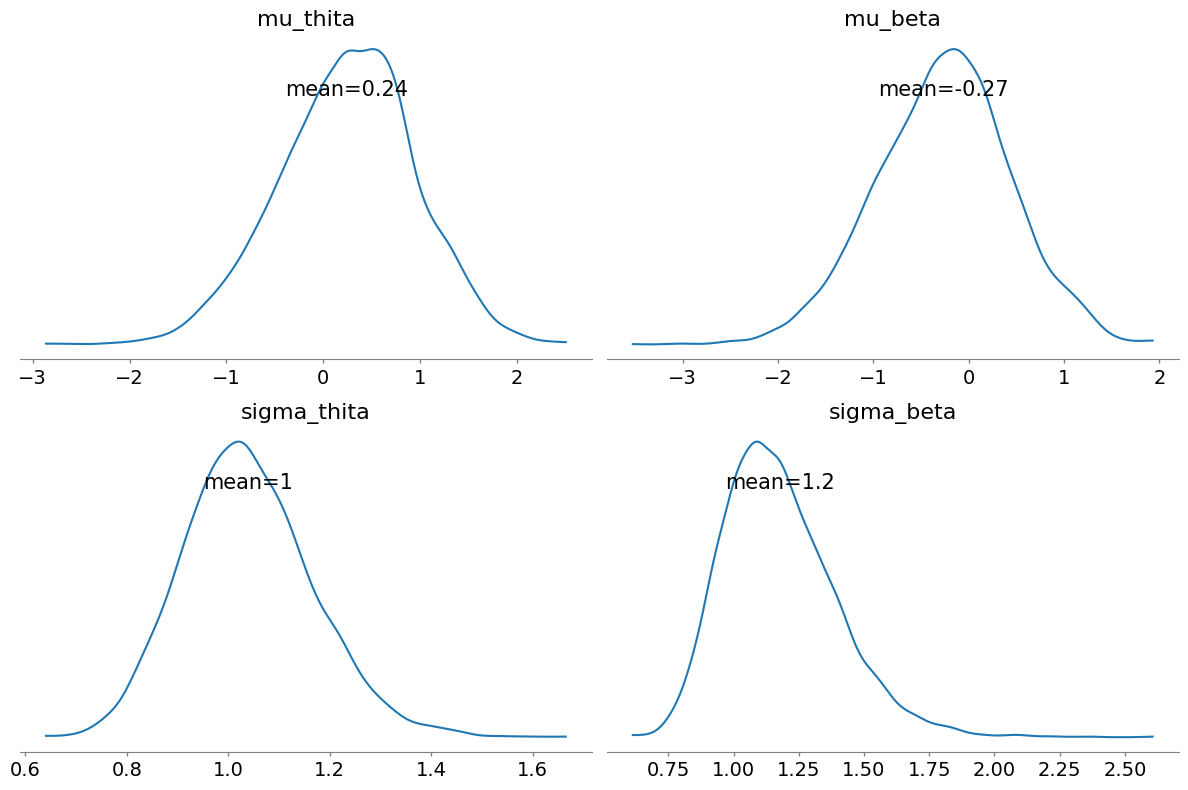

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

az.plot_posterior(trace, var_names=["mu_thita"], hdi_prob = 'hide', ax=axes[0, 0])

az.plot_posterior(trace, var_names=["mu_beta"],  hdi_prob = 'hide', ax=axes[0, 1])

az.plot_posterior(trace, var_names=["sigma_thita"], hdi_prob = 'hide', ax=axes[1, 0])

az.plot_posterior(trace, var_names=["sigma_beta"], hdi_prob = 'hide', ax=axes[1, 1])


plt.tight_layout()
plt.show()

#f) Utilizar los valores muestreados para aproximar la probabilidad predictiva de que el usuario i−ésimo resuelva la tarea j−ésima sobre los datos faltantes (debe indicar un resultado por cadena). Indicar la probabilidad de que el usuario 4 resuleva la tarea 12

In [ ]:
theta_exp = thita_muestras[:, :, :, None]  #(chains, draws, N_usuarios, 1)
beta_exp  = beta_muestras[:, :, None, :]   #(chains, draws, 1, N_tareas)

p_pred = 1/(1 + np.exp(-theta_exp + beta_exp)) #(chains, draws, N_usuarios, N_tareas)
p_pred = np.mean(p_pred, axis = 1) #(chains, N_usuarios, N_tareas)

print(f'Las probabilidad de que el usuario 4 resuelva la tarea 12 según las 3 cadenas son: {p_pred[0, 4, 12]:.3f}, {p_pred[1, 4, 12]:.3f} y {p_pred[2, 4, 12]:.3f}')

Las probabilidad de que el usuario 4 resuelva la tarea 12 según las 3 cadenas son: 0.869, 0.869 y 0.870
